In [1]:
!python -m pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\Matebook X\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully ")

Libraries loaded successfully 


In [11]:
import pandas as pd

try:
    df = pd.read_csv('../data/creditcard.csv')  # Make sure file name is correct
    print("Dataset loaded successfully")
    print(df.head())

except FileNotFoundError:
    print("File not found. Make sure 'creditcard.csv' is in the same folder")
    df = None

Dataset loaded successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [12]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21   

In [14]:
# Standardize column name (correct dataset column is 'Amount')
if 'Amount' in df.columns:
    df.rename(columns={'Amount': 'transaction_amount'}, inplace=True)

# Convert to numeric safelydf['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

# Remove missing values
df = df.dropna()

# Remove zero or negative values
df = df[df['transaction_amount'] > 0]

print("Data cleaned successfully")

df.head()

Data cleaned successfully


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,transaction_amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# Calculate mean and standard deviation
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

print("Mean:", mean)
print("Standard Deviation:", std)

# Avoid division error
if std == 0:
    print("Standard deviation is zero. Cannot compute Z-score.")
else:
    df['Z_Score'] = (df['transaction_amount'] - mean) / std

# Display result
df.head()

Mean: 88.91940126933868
Standard Deviation: 250.82437352290583


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,transaction_amount,Class,Z_Score
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.242004
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.343784
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.155153
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.137868
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.075469


In [18]:
# Mark anomalies
df['Anomaly'] = df['Z_Score'].apply(lambda x: 'Yes' if abs(x) > 3 else 'No')

# Extract anomalies
anomalies = df[df['Anomaly'] == 'Yes']

print("Total Anomalies Found:", len(anomalies))

anomalies.head()

Total Anomalies Found: 4058


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,transaction_amount,Class,Z_Score,Anomaly
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0,5.238847,Yes
89,59.0,-0.773293,-4.146007,-0.932038,0.027094,-1.698307,0.460188,0.737344,-0.314216,-0.842673,...,-1.134769,-0.654958,0.098386,-0.209150,-0.171709,0.208057,1142.02,0,4.198558,Yes
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,...,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0,3.311802,Yes
150,93.0,-1.640014,-0.479831,1.613630,2.997979,-3.803788,5.051812,3.315254,-0.303785,0.671395,...,-0.405779,-1.268700,0.494090,0.610967,0.608993,-0.410034,937.69,0,3.383924,Yes
164,103.0,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,...,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0,14.907326,Yes


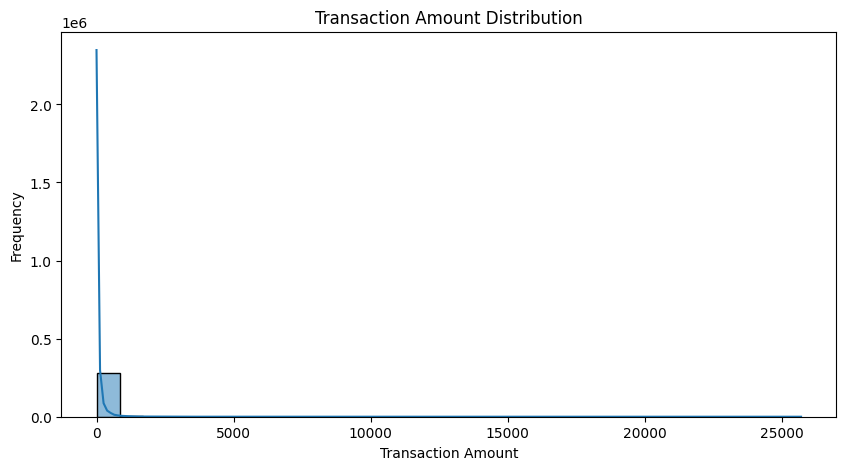

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['transaction_amount'], bins=30, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

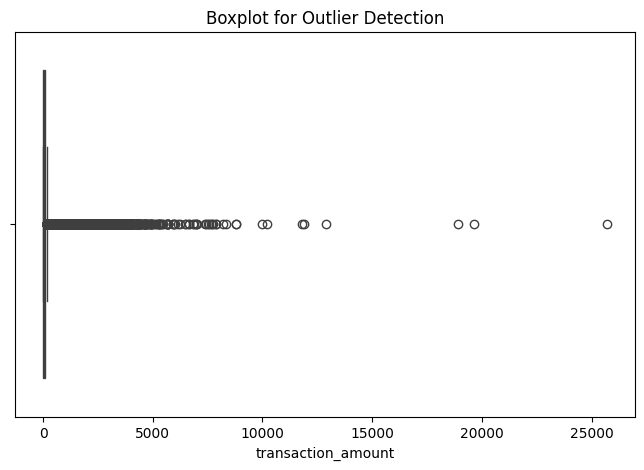

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['transaction_amount'])

plt.title("Boxplot for Outlier Detection")

plt.show()

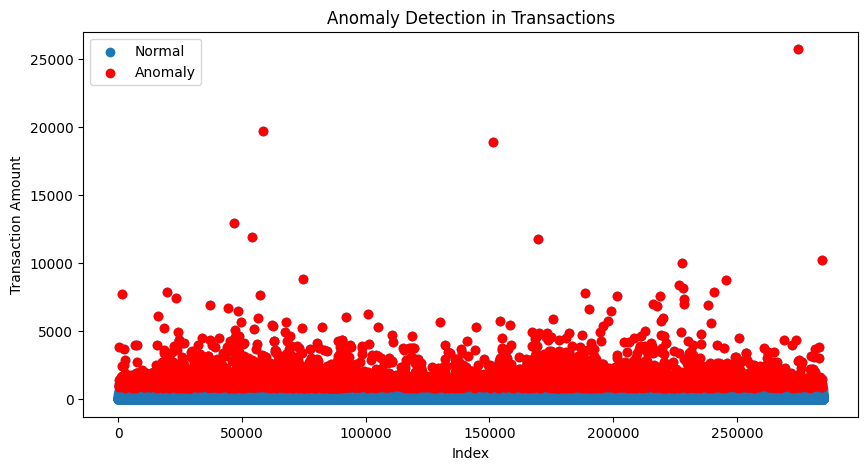

In [22]:
plt.figure(figsize=(10,5))

# Normal points
plt.scatter(df.index, df['transaction_amount'], label='Normal')

# Highlight anomalies
plt.scatter(anomalies.index, anomalies['transaction_amount'], color='red', label='Anomaly')

plt.title("Anomaly Detection in Transactions")
plt.xlabel("Index")
plt.ylabel("Transaction Amount")

plt.legend()
plt.show()

In [23]:
# Save results
df.to_csv('results.csv', index=False)

print("Results saved successfully ")

Results saved successfully 


In [24]:
print("Top Anomalies:")

anomalies.sort_values(by='transaction_amount', ascending=False).head()

Top Anomalies:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,transaction_amount,Class,Z_Score,Anomaly
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.16,0,102.072379,Yes
58465,48401.0,-36.802320,-63.344698,-20.645794,16.715537,-20.672064,7.694002,24.956587,-4.730111,-2.687312,...,-17.173665,1.180700,-7.025783,-2.534330,-3.602479,3.450224,19656.53,0,78.013194,Yes
151296,95286.0,-34.549296,-60.464618,-21.340854,16.875344,-19.229075,6.335259,24.422716,-4.964566,0.188912,...,-16.513186,0.744341,-7.081325,-2.604551,-3.550963,3.250802,18910.00,0,75.036889,Yes
46841,42951.0,-23.712839,-42.172688,-13.320825,9.925019,-13.945538,5.564891,15.710644,-2.844253,-1.580725,...,-11.310338,0.404175,-4.547278,-1.577118,-2.357385,2.253662,12910.93,0,51.119476,Yes
54018,46253.0,-21.780665,-38.305310,-12.122469,9.752791,-12.880794,4.256017,14.785051,-2.818253,-0.667338,...,-10.547038,0.653249,-4.232409,-0.480459,-2.257913,2.082488,11898.09,0,47.081432,Yes
